# Analysis: EOFs, site extraction, saving

Three things that come up constantly and are easy to get wrong by hand: empirical
orthogonal functions, pulling a model timeseries out at a set of site coordinates,
and writing a derived field back to disk.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
case = x4c.Timeseries(case_dir, grid_dict={'atm': 'ne16np4', 'ocn': 'g16'},
                      cesm_ver=1)
case.load('TS', timespan=(1, 10), verbose=False)

# EOFs need a regular grid, so regrid off the spectral-element grid first
ts = case.ds['TS'].x.regrid(2, 2).x.da
print(dict(ts.sizes))

>>> case.root_dir: /glade/u/home/fengzhu/.cache/x4c/sample_data/cesm1_sample_data/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.path_pattern: comp/proc/tseries/*/casename.hstr.vn.timespan.nc
>>> case.grid_dict: {'atm': 'ne16np4', 'ocn': 'g16', 'lnd': 'ne16np4', 'rof': 'ne16np4', 'ice': 'g16'}
>>> case.casename: b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.paths["atm"]["cam.h0"] created
>>> case.paths["ocn"]["pop.h"] created
>>> case.paths["lnd"]["clm2.h0"] created
>>> case.paths["ice"]["cice.h"] created
>>> case.vns["atm"]["cam.h0"] created
>>> case.vns["ocn"]["pop.h"] created
>>> case.vns["lnd"]["clm2.h0"] created
>>> case.vns["ice"]["cice.h"] created


{'time': 120, 'lat': 90, 'lon': 180}


## Grid predicates

`.x.plot()` uses these to decide what kind of plot to draw; they are also handy in
your own code when a function has to accept either a native or a regridded field.

In [3]:
native = case.ds['TS'].x.da
print('native  : is_cam_se', native.x.is_cam_se(), '| is_latlon', native.x.is_latlon(),
      '| is_map', native.x.is_map())
print('regridded: is_cam_se', ts.x.is_cam_se(), '| is_latlon', ts.x.is_latlon(),
      '| is_map', ts.x.is_map())
print('a timeseries is not a map:', ts.x.gm.x.is_map())

native  : is_cam_se True | is_latlon False | is_map True
regridded: is_cam_se False | is_latlon True | is_map True
a timeseries is not a map: False


## EOF analysis

`.x.eof(n)` returns `(pcs, eofs, variance_fractions)`. The field is weighted by
sqrt(cos(lat)) first so that the modes are area-fair rather than dominated by the
poles — pass `weight=False` to skip that.

In [4]:
anom = ts.x.anom                     # remove the monthly climatology first
pcs, eofs, var = anom.x.eof(n=3)

print('PCs  :', dict(pcs.sizes))
print('EOFs :', dict(eofs.sizes))
print('variance explained:', np.round(var.values * 100, 1), '%')

PCs  : {'time': 120, 'mode': 3}
EOFs : {'mode': 3, 'lat': 90, 'lon': 180}
variance explained: [17.3 10.2  7.6] %


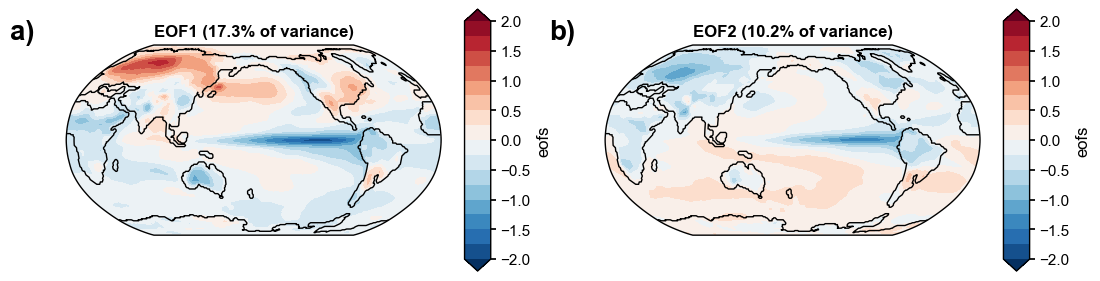

In [5]:
ssh_path = os.path.join(case_dir, 'ocn', 'proc', 'tseries', 'month_1',
                        f'{casename}.pop.h.SSH.000101-000512.nc')
ssv = x4c.open_dataset(ssh_path, comp='ocn', grid='g16', vn='SSH',
                       shift_time=True).x.regrid().x.da.mean('time')

ax_loc = {'a': (0, 0), 'b': (0, 1)}
fig, axd = x4c.subplots(1, 2, ax_loc=ax_loc,
                        projs={k: 'Robinson' for k in ax_loc},
                        projs_kws={k: {'central_longitude': 180} for k in ax_loc},
                        figsize=(13, 3.4), wspace=0.15,
                        annotation=True)

for i, k in enumerate(['a', 'b']):
    m = eofs.isel(mode=i)
    m.attrs['long_name'] = f'EOF{i + 1} ({var.values[i] * 100:.1f}% of variance)'
    m.x.plot(ax=axd[k], ssv=ssv, cmap='RdBu_r', levels=np.linspace(-2, 2, 17),
             title=m.attrs['long_name'])
x4c.showfig(fig)

`annotation=True` on `x4c.subplots` adds the `a)` `b)` panel labels; `x4c.add_annotation`
does the same to axes you built yourself.

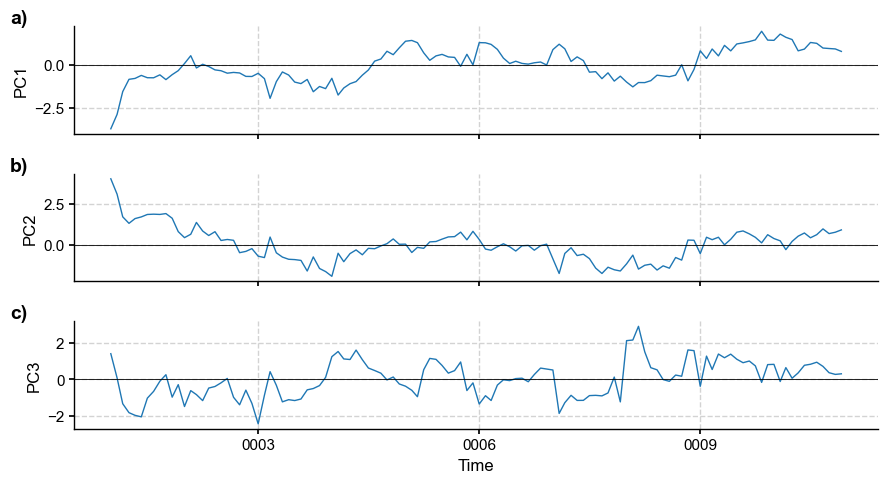

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(9, 5), sharex=True)
for i, axi in enumerate(axes):
    axi.plot(pcs.time, pcs.isel(mode=i), lw=1)
    axi.axhline(0, color='k', lw=0.6)
    axi.set_ylabel(f'PC{i + 1}')
axes[-1].set_xlabel('Time')
x4c.add_annotation(list(axes), style=')', loc_x=-0.08, fs=14)
fig.tight_layout()
x4c.showfig(fig)

## Extracting sites

`.x.nearest2d()` finds the nearest **non-NaN** grid cell to each target coordinate, which
matters over the ocean: the nearest cell to a coastal site may be land. It returns a
`site` dimension so a whole proxy network comes back as one array.

In [7]:
sites = {
    'equatorial Pacific': (0.0, 220.0),
    'north Atlantic':     (55.0, 330.0),
    'southern ocean':     (-60.0, 90.0),
}
lats = [v[0] for v in sites.values()]
lons = [v[1] for v in sites.values()]

pts = ts.x.nearest2d(lat=lats, lon=lons)
print(dict(pts.sizes))
for i, name in enumerate(sites):
    p = pts.isel(site=i)
    print(f'  {name:20s} nearest cell at lat={float(p.lat):+6.1f}, lon={float(p.lon):6.1f}'
          f'  mean TS = {float(p.mean()):.2f} K')

{'site': 3, 'time': 120}


  equatorial Pacific   nearest cell at lat=  -1.0, lon= 219.0  mean TS = 304.40 K


  north Atlantic       nearest cell at lat= +55.0, lon= 329.0  mean TS = 285.79 K


  southern ocean       nearest cell at lat= -61.0, lon=  89.0  mean TS = 284.37 K


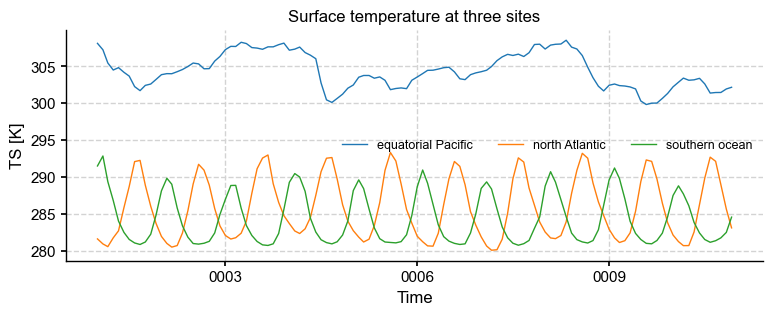

In [8]:
fig, ax = plt.subplots(figsize=(9, 3))
for i, name in enumerate(sites):
    ax.plot(pts.time, pts.isel(site=i), lw=1, label=name)
ax.legend(frameon=False, ncol=3, fontsize=9)
ax.set(xlabel='Time', ylabel='TS [K]', title='Surface temperature at three sites')
x4c.showfig(fig)

### Three-dimensional sites

`.x.nearest3d()` does the same in depth as well, combining horizontal great-circle
distance with the vertical offset. It works straight on the native POP grid, where
latitude and longitude are 2-D arrays.

Target depths are given in metres; `depth_unit` describes the model coordinate
(`'cm'` for POP).

In [9]:
case.load('TEMP', timespan=(1, 1), verbose=False)
temp = case.ds['TEMP'].x.da

pts3 = temp.x.nearest3d(
    lat=[0.0, -60.0], lon=[220.0, 90.0], depth=[25.0, 75.0],
    lat_coord='TLAT', lon_coord='TLONG', lat_dim='nlat', lon_dim='nlon',
    depth_coord='z_t', depth_dim='z_t', depth_unit='cm',
)
print(dict(pts3.sizes))
for i in range(pts3.sizes['site']):
    p = pts3.isel(site=i)
    print(f'  site {i}: lat={float(p.TLAT):+6.1f} lon={float(p.TLONG):6.1f} '
          f'z={float(p.z_t) / 100:6.1f} m  mean TEMP = {float(p.mean()):.2f} degC')

{'site': 2, 'time': 12}


  site 0: lat=  -0.3 lon= 219.6 z=  25.0 m  mean TEMP = 30.30 degC


  site 1: lat= -60.1 lon=  90.3 z=  75.0 m  mean TEMP = 8.50 degC


## Saving derived fields

Use **`.x.to_netcdf()`**, not the bare xarray method. `x4c` carries the grid metadata
(`gw`, `lat`, `lon`, `dz`) as `.attrs`, and those are `DataArray`s — netCDF attributes
have to be scalars or strings, so a plain `to_netcdf` fails.

`.x.to_netcdf()` strips them from a **copy**, so the object you still hold keeps its
weights and stays usable afterwards.

In [10]:
gmst = case.calc('GMST ~ TS:ann:gm', timespan=(1, 10), verbose=False)
out_path = 'gmst_ann.nc'

gmst.x.to_netcdf(out_path)
print('wrote', out_path, f'({os.path.getsize(out_path) / 1024:.1f} KB)')

# the in-memory object is untouched
print('still has gw? ', 'gw' in case.ds['TS'].x.da.attrs)

>>> Timespan: [0001-01-01 00:00:00, 0010-12-01 00:00:00]


wrote gmst_ann.nc (9.9 KB)
still has gw?  True


In [11]:
back = xr.open_dataset(out_path)
print(back)
back.close()
os.remove(out_path)

<xarray.Dataset> Size: 160B
Dimensions:  (time: 10)
Coordinates:
  * time     (time) object 80B 0001-12-31 00:00:00 ... 0010-12-31 00:00:00
Data variables:
    GMST     (time) float64 80B ...


A plain `to_netcdf` on a field that still carries the grid attrs raises — worth
seeing once so the error is recognisable.

In [12]:
da = case.ds['TS'].x.da
try:
    da.to_netcdf('should_fail.nc')
except TypeError as e:
    print('TypeError:', str(e)[:120], '...')
finally:
    if os.path.exists('should_fail.nc'):
        os.remove('should_fail.nc')

TypeError: Invalid value for attr 'gw': <xarray.DataArray 'area' (ncol: 13826)> Size: 111kB
dask.array<where, shape=(13826,), dtype ...
